# CIFAR-10 Unified Classifier Notebook
### FCNN (PyTorch) · CNN (PyTorch) · Qwen3-VL-8B-Instruct (VLM) · Gemma-4-31B-IT (VLM) · Gemma-4-31B Heretic2 (VLM)

This notebook runs five classifiers on CIFAR-10 in order:
1. **Fully-Connected Neural Network** (PyTorch) — trained, with learning curves
2. **Convolutional Neural Network** (PyTorch) — trained, with learning curves
3. **Qwen/Qwen3-VL-8B-Instruct** (HuggingFace, zero-shot VLM)
4. **Gemma-4-31B-IT** (HuggingFace, zero-shot VLM)
5. **Gemma-4-31B Heretic2** (Abliterated, zero-shot VLM)

A shared `NUM_SAMPLES` variable at the top controls how many test images the VLM sections evaluate.

---
## Section 0 — Install Dependencies

In [25]:
# Run once. Restart the kernel after installing if needed.
#!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/rocm6.2
#!pip install -U transformers
!pip install -U accelerate pillow huggingface_hub ipywidgets matplotlib scikit-learn tqdm qwen-vl-utils --break-system-packages  

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 71.9 MB/s  0:00:00


---
## Section 0b — Global Configuration

Set `NUM_SAMPLES` here. Both VLM sections (Gemma-4 and Gemma-4 Heretic2) will use this value.
The CNN/FCNN sections train and evaluate on the full dataset.

In [26]:
# ── Global configuration ───────────────────────────────────────────────────
NUM_SAMPLES = 10000   # Number of CIFAR-10 test images for VLM evaluation.
                    # Set to len(test_dataset) for a full run (slow!).
RANDOM_SEED = 42    # For reproducible subset selection.
# ────────────────────────────────────────────────────────────────────────────

import gc

# ── Subset evaluation + confusion matrix (NUM_SAMPLES, shared indices) ──
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

LABELS = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

SYSTEM_PROMPT = (
    "You are an image classification assistant. "
    "You will be shown a small 32x32 pixel image. "
    "Your task is to classify it into exactly one of these ten categories: "
    + ", ".join(LABELS) + ". "
    "Reply with ONLY the category name — nothing else, no punctuation, no explanation."
)

# ── Shared evaluation indices (generated once, used by ALL sections) ──────
# All five classifiers (FCNN, CNN, Qwen, Gemma-4, Heretic2) evaluate on this
# exact same subset so results are directly comparable.
import numpy as np
_rng    = np.random.default_rng(RANDOM_SEED)
# Note: CIFAR-10 test set has 10 000 images; indices are into that set.
# We use 10 000 as the upper bound here; the actual dataset length is
# validated in Section 1 after the data is downloaded.
indices = _rng.choice(10_000, size=NUM_SAMPLES, replace=False)

print(f"NUM_SAMPLES  = {NUM_SAMPLES}")
print(f"RANDOM_SEED  = {RANDOM_SEED}")
print(f"INDICES      = {NUM_SAMPLES} indices drawn from [0, 10 000)")
print(f"LABELS       = {LABELS}")


NUM_SAMPLES  = 10000
RANDOM_SEED  = 42
INDICES      = 10000 indices drawn from [0, 10 000)
LABELS       = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [27]:
# ── GPU / Device Debug ────────────────────────────────────────────────────
import torch

print("=" * 55)
print("  DEVICE DIAGNOSTICS")
print("=" * 55)
print(f"  PyTorch version     : {torch.__version__}")
print(f"  CUDA available      : {torch.cuda.is_available()}")
print(f"  CUDA device count   : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        mem_total = props.total_memory / 1024**3
        mem_alloc = torch.cuda.memory_allocated(i) / 1024**3
        mem_reserv = torch.cuda.memory_reserved(i) / 1024**3
        print(f"  GPU {i}: {props.name}")
        print(f"    Compute capability : {props.major}.{props.minor}")
        print(f"    Total VRAM         : {mem_total:.2f} GB")
        print(f"    Allocated          : {mem_alloc:.3f} GB")
        print(f"    Reserved           : {mem_reserv:.3f} GB")
    device = torch.device('cuda')
    # Quick tensor round-trip to confirm CUDA actually works
    _t = torch.tensor([1.0]).to(device)
    print(f"  Tensor device test  : {_t.device}  ✓")
    del _t
else:
    device = torch.device('cpu')
    print("  *** NO CUDA DETECTED — running on CPU ***")
    try:
        import subprocess, re
        out = subprocess.check_output(['rocm-smi'], stderr=subprocess.STDOUT).decode()
        print("  nvidia-smi output:")
        print(out[:800])
    except Exception as e:
        print(f"  nvidia-smi not available: {e}")

print(f"  Active device       : {device}")
print("=" * 55)


  DEVICE DIAGNOSTICS
  PyTorch version     : 2.10.0
  CUDA available      : True
  CUDA device count   : 1
  GPU 0: Radeon 8060S Graphics
    Compute capability : 11.5
    Total VRAM         : 112.00 GB
    Allocated          : 0.031 GB
    Reserved           : 0.031 GB
  Tensor device test  : cuda:0  ✓
  Active device       : cuda


---
## Section 1 — Load CIFAR-10

We load CIFAR-10 once and share it across all sections.
- PyTorch models receive normalised float tensors.
- VLM models receive PIL images converted from raw [0,1] float tensors.

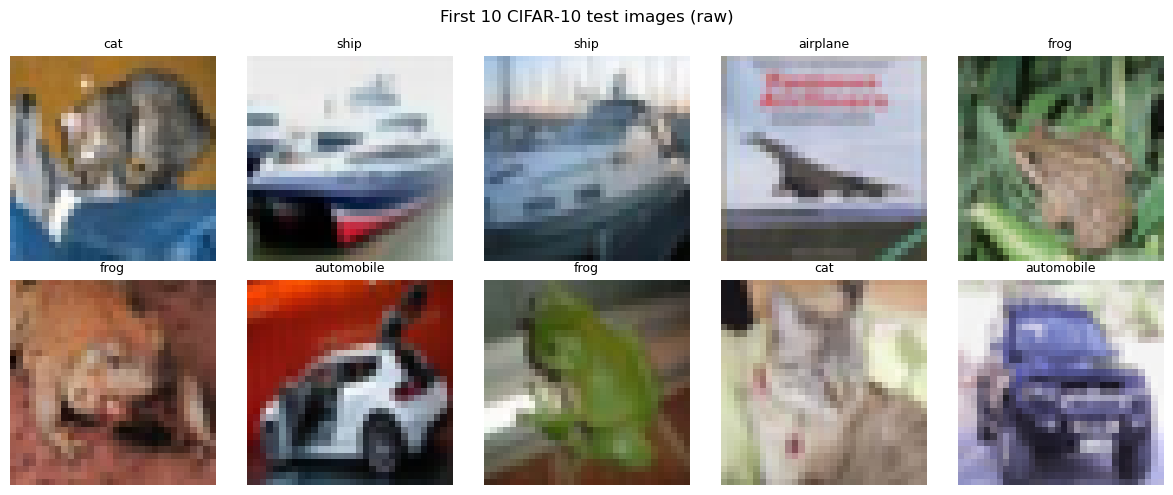

Train: 50000 images | Test: 10000 images
Image shape: torch.Size([3, 32, 32])


In [28]:
import torch
import torchvision
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ── Raw transform: C×H×W float32 in [0,1]  (for VLM) ─────────────────────
raw_transform = T.ToTensor()

# ── Normalised transform: for PyTorch FCNN / CNN ──────────────────────────
norm_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),   # CIFAR-10 per-channel mean
                (0.2023, 0.1994, 0.2010)),   # CIFAR-10 per-channel std
])

# Raw (VLM) datasets
raw_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=raw_transform)
raw_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=raw_transform)

# Normalised (CNN/FCNN) datasets
norm_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=False, transform=norm_transform)
norm_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=False, transform=norm_transform)

train_loader = torch.utils.data.DataLoader(norm_train, batch_size=128,
                                            shuffle=True,  num_workers=2)
test_loader  = torch.utils.data.DataLoader(norm_test,  batch_size=128,
                                            shuffle=False, num_workers=2)

def tensor_to_pil(t: torch.Tensor) -> Image.Image:
    """Convert a C*H*W float32 [0,1] tensor → PIL RGB image (no preprocessing)."""
    arr = (t.clamp(0, 1) * 255).byte().permute(1, 2, 0).numpy()
    return Image.fromarray(arr, mode='RGB')

# Sanity-check grid
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.ravel(), range(10)):
    img_t, lbl = raw_test[idx]
    ax.imshow(tensor_to_pil(img_t))
    ax.set_title(LABELS[lbl], fontsize=9)
    ax.axis('off')
plt.suptitle('First 10 CIFAR-10 test images (raw)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Train: {len(norm_train)} images | Test: {len(norm_test)} images")
print(f"Image shape: {norm_train[0][0].shape}")

---
## Section 2 — Fully-Connected Neural Network (PyTorch)

Architecture mirrors the original Keras FCNN:
- `Flatten → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10)`
- Trained for **200 epochs** with Adam and cross-entropy loss.
- Learning curves plotted after training.
- Single-image demo (index 62) and confusion matrix on the full test set.

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Model ─────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.net(x)

fcnn = FCNN().to(device)
print(fcnn)

criterion   = nn.CrossEntropyLoss()
fcnn_optim  = optim.Adam(fcnn.parameters(), lr=1e-3)

FCNN_EPOCHS = 75

fcnn_train_loss, fcnn_val_loss   = [], []
fcnn_train_acc,  fcnn_val_acc    = [], []

print(f"\nTraining FCNN for {FCNN_EPOCHS} epochs ...")

for epoch in tqdm(range(1, FCNN_EPOCHS + 1), desc='FCNN'):
    # ── Train ──────────────────────────────────────────────────────────────
    fcnn.train()
    running_loss, running_correct, n = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        fcnn_optim.zero_grad()
        out  = fcnn(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        fcnn_optim.step()
        running_loss    += loss.item() * imgs.size(0)
        running_correct += out.argmax(1).eq(lbls).sum().item()
        n               += imgs.size(0)
    fcnn_train_loss.append(running_loss / n)
    fcnn_train_acc.append( running_correct / n)

    # ── Validate ───────────────────────────────────────────────────────────
    fcnn.eval()
    val_loss, val_correct, val_n = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = fcnn(imgs)
            loss = criterion(out, lbls)
            val_loss    += loss.item() * imgs.size(0)
            val_correct += out.argmax(1).eq(lbls).sum().item()
            val_n       += imgs.size(0)
    fcnn_val_loss.append(val_loss / val_n)
    fcnn_val_acc.append( val_correct / val_n)

print("FCNN training complete.")

Using device: cuda
FCNN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

Training FCNN for 75 epochs ...


FCNN:   0%|          | 0/75 [00:00<?, ?it/s]

FCNN training complete.


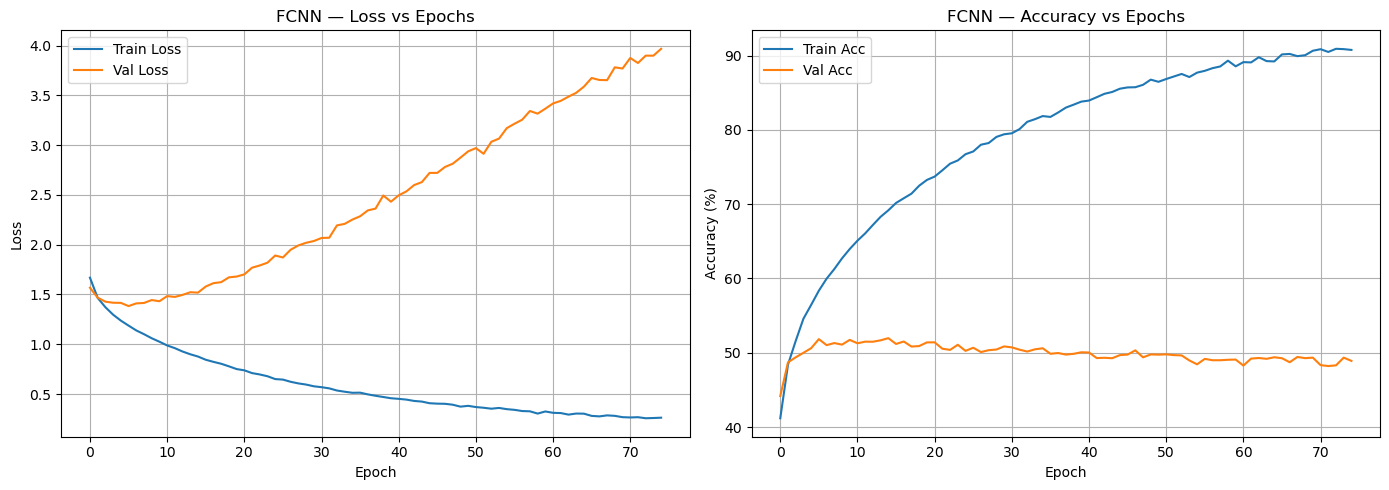

In [30]:
# ── Learning curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fcnn_train_loss, label='Train Loss')
ax1.plot(fcnn_val_loss,   label='Val Loss')
ax1.set_title('FCNN — Loss vs Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot([a * 100 for a in fcnn_train_acc], label='Train Acc')
ax2.plot([a * 100 for a in fcnn_val_acc],   label='Val Acc')
ax2.set_title('FCNN — Accuracy vs Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

FCNN predicts : frog
True label    : frog
Correct       : True


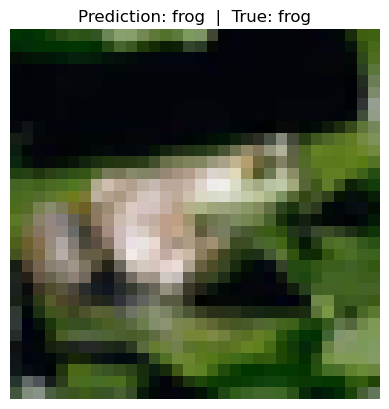

In [31]:
# ── Single-image demo (index 62, matching original notebook) ──────────────
fcnn.eval()
i = 62
img_norm, true_lbl = norm_test[i]
img_raw,  _        = raw_test[i]

with torch.no_grad():
    logits = fcnn(img_norm.unsqueeze(0).to(device))
pred_lbl = LABELS[logits.argmax(1).item()]

print(f"FCNN predicts : {pred_lbl}")
print(f"True label    : {LABELS[true_lbl]}")
print(f"Correct       : {pred_lbl == LABELS[true_lbl]}")

plt.imshow(tensor_to_pil(img_raw))
plt.title(f"Prediction: {pred_lbl}  |  True: {LABELS[true_lbl]}", fontsize=12)
plt.axis('off')
plt.show()

FCNN subset test accuracy (10000 samples): 48.91%


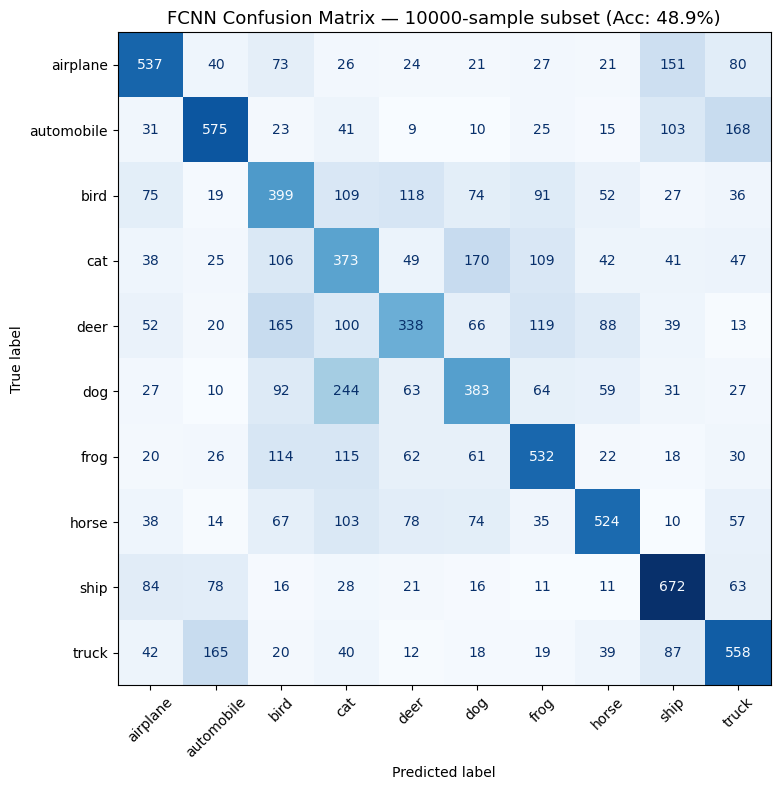

In [32]:
import numpy as np

fcnn.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for idx in indices:
        img_norm, lbl = norm_test[int(idx)]
        pred = fcnn(img_norm.unsqueeze(0).to(device)).argmax(1).item()
        all_preds.append(pred)
        all_true.append(lbl)

fcnn_acc = sum(p == t for p, t in zip(all_preds, all_true)) / len(all_true) * 100
print(f"FCNN subset test accuracy ({NUM_SAMPLES} samples): {fcnn_acc:.2f}%")

cm = confusion_matrix(all_true, all_preds, labels=range(10))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, colorbar=False,
                                                        cmap='Blues',
                                                        xticks_rotation=45)
ax.set_title(f'FCNN Confusion Matrix — {NUM_SAMPLES}-sample subset (Acc: {fcnn_acc:.1f}%)',
             fontsize=13)
plt.tight_layout()
plt.show()


In [33]:
# ── Free FCNN from GPU memory ──────────────────────────────────────
del fcnn, fcnn_optim
gc.collect()
torch.cuda.empty_cache()
print("FCNN memory freed.")

FCNN memory freed.


---
## Section 3 — Convolutional Neural Network (PyTorch)

Architecture mirrors the original Keras CNN:
- `Conv(32)→Pool → Conv(64)→Pool → Conv(64) → Flatten → Dense(64) → Dense(10)`
- Trained for **50 epochs** with Adam and cross-entropy loss.
- Learning curves, single-image demo (index 62), and confusion matrix.

In [34]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.ReLU(),
            nn.MaxPool2d(2),                 # 16×16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                 # 8×8
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

cnn = CNN().to(device)
print(cnn)

cnn_optim = optim.Adam(cnn.parameters(), lr=1e-3)

CNN_EPOCHS = 20

cnn_train_loss, cnn_val_loss = [], []
cnn_train_acc,  cnn_val_acc  = [], []

print(f"\nTraining CNN for {CNN_EPOCHS} epochs ...")

for epoch in tqdm(range(1, CNN_EPOCHS + 1), desc='CNN'):
    cnn.train()
    running_loss, running_correct, n = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        cnn_optim.zero_grad()
        out  = cnn(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        cnn_optim.step()
        running_loss    += loss.item() * imgs.size(0)
        running_correct += out.argmax(1).eq(lbls).sum().item()
        n               += imgs.size(0)
    cnn_train_loss.append(running_loss / n)
    cnn_train_acc.append( running_correct / n)

    cnn.eval()
    val_loss, val_correct, val_n = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = cnn(imgs)
            loss = criterion(out, lbls)
            val_loss    += loss.item() * imgs.size(0)
            val_correct += out.argmax(1).eq(lbls).sum().item()
            val_n       += imgs.size(0)
    cnn_val_loss.append(val_loss / val_n)
    cnn_val_acc.append( val_correct / val_n)

print("CNN training complete.")

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)

Training CNN for 20 epochs ...


CNN:   0%|          | 0/20 [00:00<?, ?it/s]

CNN training complete.


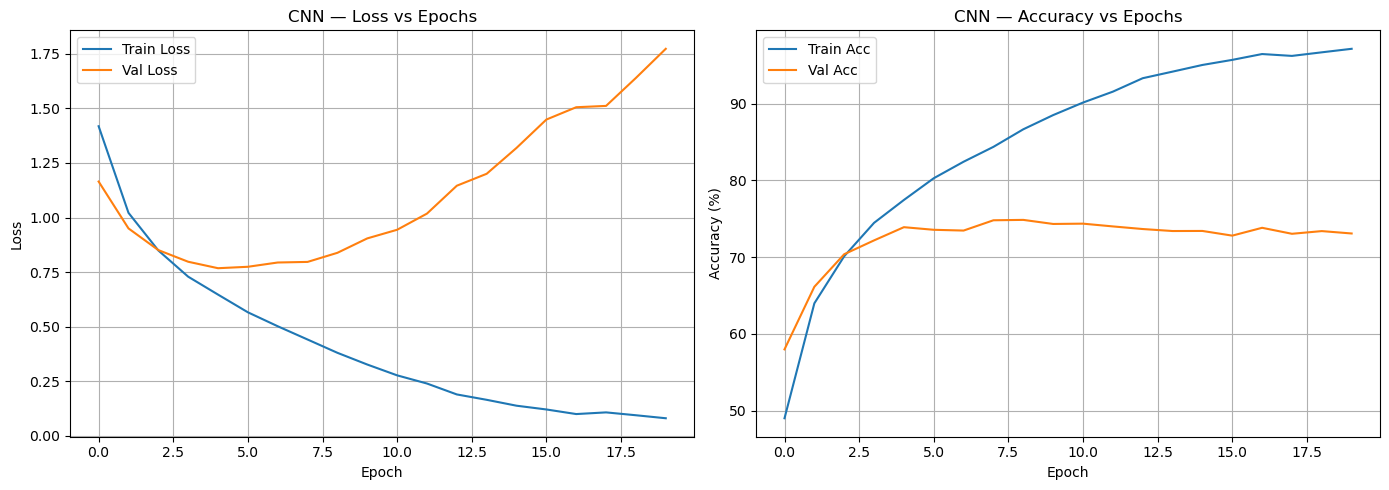

In [35]:
# ── Learning curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_train_loss, label='Train Loss')
ax1.plot(cnn_val_loss,   label='Val Loss')
ax1.set_title('CNN — Loss vs Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot([a * 100 for a in cnn_train_acc], label='Train Acc')
ax2.plot([a * 100 for a in cnn_val_acc],   label='Val Acc')
ax2.set_title('CNN — Accuracy vs Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

CNN predicts : frog
True label   : frog
Correct      : True


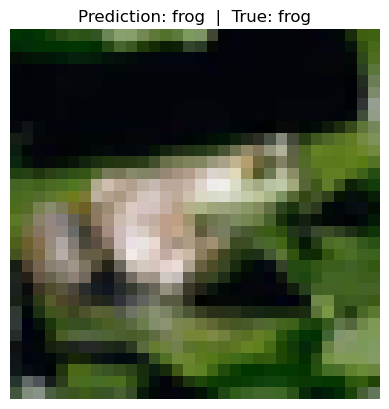

In [36]:
# ── Single-image demo (index 62) ──────────────────────────────────────────
cnn.eval()
i = 62
img_norm, true_lbl = norm_test[i]
img_raw,  _        = raw_test[i]

with torch.no_grad():
    logits = cnn(img_norm.unsqueeze(0).to(device))
pred_lbl = LABELS[logits.argmax(1).item()]

print(f"CNN predicts : {pred_lbl}")
print(f"True label   : {LABELS[true_lbl]}")
print(f"Correct      : {pred_lbl == LABELS[true_lbl]}")

plt.imshow(tensor_to_pil(img_raw))
plt.title(f"Prediction: {pred_lbl}  |  True: {LABELS[true_lbl]}", fontsize=12)
plt.axis('off')
plt.show()

CNN subset test accuracy (10000 samples): 73.08%


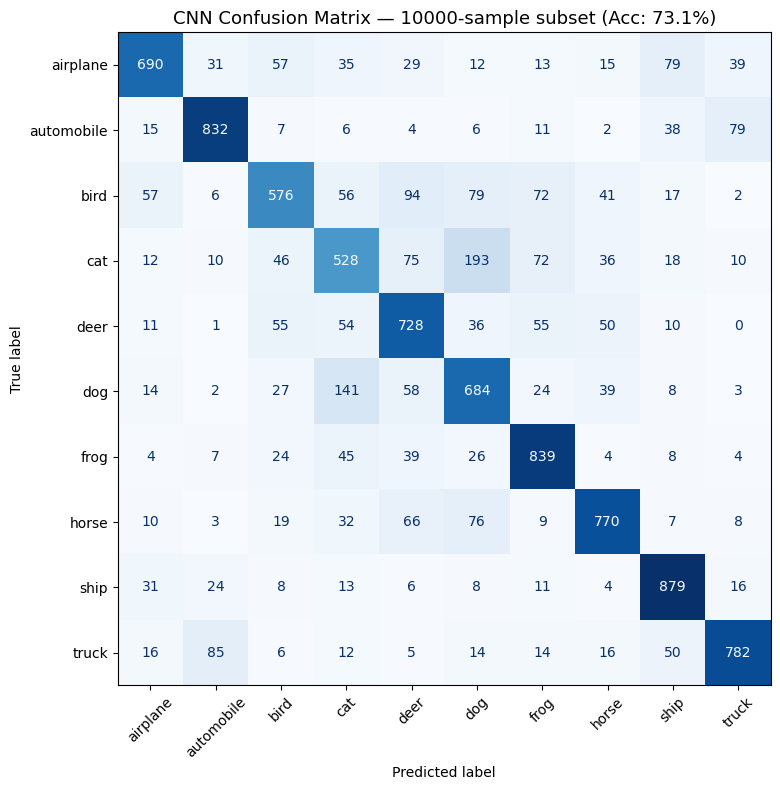

In [37]:
# ── Subset evaluation + confusion matrix (NUM_SAMPLES, shared indices) ──

cnn.eval()
all_preds_cnn, all_true_cnn = [], []
with torch.no_grad():
    for idx in indices:
        img_norm, lbl = norm_test[int(idx)]
        pred = cnn(img_norm.unsqueeze(0).to(device)).argmax(1).item()
        all_preds_cnn.append(pred)
        all_true_cnn.append(lbl)

cnn_acc = sum(p == t for p, t in zip(all_preds_cnn, all_true_cnn)) / len(all_true_cnn) * 100
print(f"CNN subset test accuracy ({NUM_SAMPLES} samples): {cnn_acc:.2f}%")

cm_cnn = confusion_matrix(all_true_cnn, all_preds_cnn, labels=range(10))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm_cnn, display_labels=LABELS).plot(ax=ax, colorbar=False,
                                                            cmap='Blues',
                                                            xticks_rotation=45)
ax.set_title(f'CNN Confusion Matrix — {NUM_SAMPLES}-sample subset (Acc: {cnn_acc:.1f}%)',
             fontsize=13)
plt.tight_layout()
plt.show()


In [14]:
# ── Free CNN from GPU memory ──────────────────────────────────────
del cnn, cnn_optim
gc.collect()
torch.cuda.empty_cache()
print("CNN memory freed.")

CNN memory freed.


---
## Section 4 — Qwen/Qwen3-VL-8B-Instruct (HuggingFace, Zero-Shot VLM)

Loads `Qwen/Qwen3-VL-8B-Instruct` from the HuggingFace Hub.  
No training — each image is passed raw to the VLM with the **same `SYSTEM_PROMPT`** used for Gemma-4.

> **Prerequisites:** Log in to HuggingFace (run the login cell in Section 5 first, or set the `HF_TOKEN` env var).

### 4a — Evaluation Notes (Qwen3-VL-8B-Instruct)

Fill in after running the evaluation below:

| Metric | Value |
|--------|-------|
| **Overall accuracy** | *(fill in after running)* |
| **Notes** | *(any observations about failure modes, refusal patterns, etc.)* |

In [40]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
import torch

QWEN_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"

print(f"Loading processor for {QWEN_MODEL_ID} ...")
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)

print(f"Loading model {QWEN_MODEL_ID} ...")
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    dtype="auto",
    device_map="auto",
)
qwen_model.eval()
print("Qwen3-VL-8B-Instruct loaded.")


Loading processor for Qwen/Qwen3-VL-8B-Instruct ...
Loading model Qwen/Qwen3-VL-8B-Instruct ...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Qwen3-VL-8B-Instruct loaded.


In [41]:
def qwen_recognize_batch(images, processor, model, max_new_tokens: int = 5) -> list[str]:
    """Batched zero-shot CIFAR-10 classification using Qwen3-VL."""
    pil_images = [
        tensor_to_pil(img) if isinstance(img, torch.Tensor) else img
        for img in images
    ]

    # Build one message list per image
    batch_messages = [
        [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
            {"role": "user",   "content": [
                {"type": "image", "image": pil},
                {"type": "text",  "text": "What object is in this image?"},
            ]},
        ]
        for pil in pil_images
    ]

    texts = [
        processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        for msgs in batch_messages
    ]
    image_inputs = [process_vision_info(msgs)[0][0] for msgs in batch_messages]

    inputs = processor(
        text=texts,
        images=image_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False
        )

    results = []
    for out in generated_ids:
        text = processor.decode(out[input_len:], skip_special_tokens=True).strip().lower()
        matched = next((l for l in LABELS if l in text), text)
        results.append(matched)
    return results

# Keep single-image wrapper for the demo cells
def qwen_recognize(image, processor, model, max_new_tokens: int = 5) -> str:
    return qwen_recognize_batch([image], processor, model, max_new_tokens)[0]

print("qwen_recognize / qwen_recognize_batch defined.")


qwen_recognize / qwen_recognize_batch defined.


#### 4b — Single-Image Demo (index 62)

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Qwen3-VL predicts : frog
True label        : frog
Correct           : True


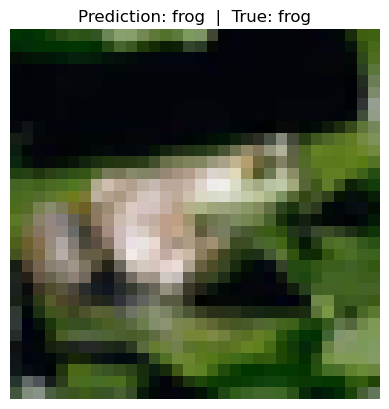

In [42]:
i = 62
img_tensor, true_label_idx = raw_test[i]

pred_qwen  = qwen_recognize(img_tensor, qwen_processor, qwen_model)
true_label = LABELS[true_label_idx]

print(f"Qwen3-VL predicts : {pred_qwen}")
print(f"True label        : {true_label}")
print(f"Correct           : {pred_qwen == true_label}")

plt.imshow(tensor_to_pil(img_tensor))
plt.title(f"Prediction: {pred_qwen}  |  True: {true_label}", fontsize=12)
plt.axis('off')
plt.show()


#### 4c — Batch Evaluation ({NUM_SAMPLES} images)

In [43]:
import time
from tqdm.auto import tqdm

QWEN_BATCH_SIZE = 16

qwen_preds, qwen_true = [], []
qwen_refusals = 0
start_q = time.time()

idx_list = list(indices)
for batch_start in tqdm(range(0, len(idx_list), QWEN_BATCH_SIZE), desc="Qwen3-VL"):
    batch_idx = idx_list[batch_start : batch_start + QWEN_BATCH_SIZE]
    imgs  = [raw_test[int(i)][0] for i in batch_idx]
    lbls  = [raw_test[int(i)][1] for i in batch_idx]
    preds = qwen_recognize_batch(imgs, qwen_processor, qwen_model)
    for pred, lbl in zip(preds, lbls):
        if pred not in LABELS:
            qwen_refusals += 1
        qwen_preds.append(pred)
        qwen_true.append(LABELS[lbl])

elapsed_q     = time.time() - start_q
n_correct_q   = sum(p == t for p, t in zip(qwen_preds, qwen_true) if p in LABELS)
qwen_accuracy = n_correct_q / NUM_SAMPLES * 100

print(f"\nEvaluated {NUM_SAMPLES} images in {elapsed_q/60:.1f} min")
print(f"Refusals (invalid labels) : {qwen_refusals}")
print(f"Zero-shot accuracy        : {qwen_accuracy:.1f}%  ({n_correct_q}/{NUM_SAMPLES})")


Qwen3-VL:   0%|          | 0/625 [00:00<?, ?it/s]


Evaluated 10000 images in 38.5 min
Refusals (invalid labels) : 3
Zero-shot accuracy        : 94.6%  (9457/10000)


#### 4d — Per-Class Accuracy

Class         Correct   Total     Acc
--------------------------------------
airplane          939    1000   93.9%
automobile        893    1000   89.3%
bird              944    1000   94.4%
cat               915    1000   91.5%
deer              941    1000   94.1%
dog               859    1000   85.9%
frog              987    1000   98.7%
horse             993    1000   99.3%
ship              987    1000   98.7%
truck             999    1000   99.9%


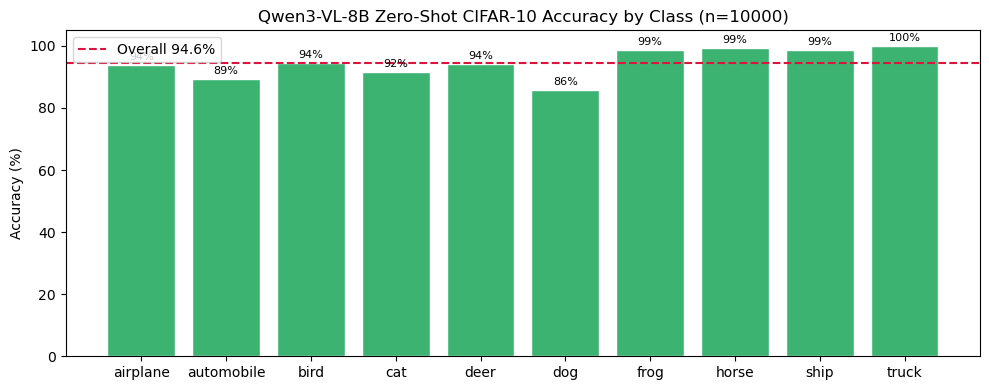

In [44]:
from collections import defaultdict

q_class_correct = defaultdict(int)
q_class_total   = defaultdict(int)

for pred, true in zip(qwen_preds, qwen_true):
    q_class_total[true] += 1
    if pred == true:
        q_class_correct[true] += 1

print(f"{'Class':<12}  {'Correct':>7}  {'Total':>6}  {'Acc':>6}")
print("-" * 38)
for label in LABELS:
    n   = q_class_total[label]
    c   = q_class_correct[label]
    acc = c / n * 100 if n > 0 else 0
    print(f"{label:<12}  {c:>7}  {n:>6}  {acc:>5.1f}%")

accs_q = [q_class_correct[l] / q_class_total[l] * 100 if q_class_total[l] > 0 else 0
          for l in LABELS]
plt.figure(figsize=(10, 4))
bars = plt.bar(LABELS, accs_q, color='mediumseagreen', edgecolor='white')
plt.axhline(qwen_accuracy, color='crimson', linestyle='--',
            label=f'Overall {qwen_accuracy:.1f}%')
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title(f'Qwen3-VL-8B Zero-Shot CIFAR-10 Accuracy by Class (n={NUM_SAMPLES})')
plt.legend()
for bar, acc in zip(bars, accs_q):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


#### 4e — Confusion Matrix

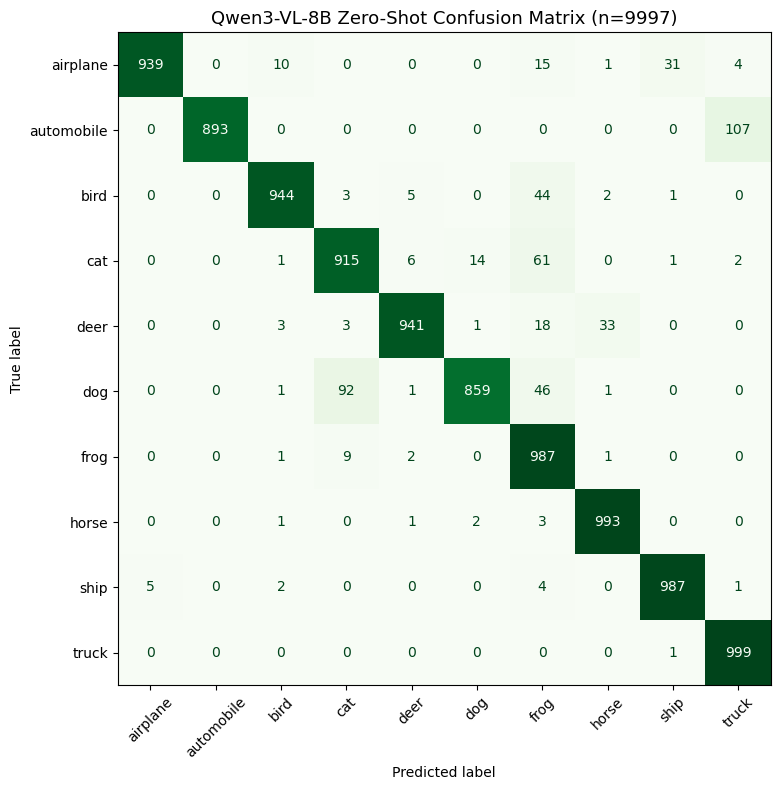

In [45]:
def label_to_idx(label):
    return LABELS.index(label) if label in LABELS else -1

y_true_q = [label_to_idx(l) for l in qwen_true]
y_pred_q = [label_to_idx(l) for l in qwen_preds]
pairs_q  = [(t, p) for t, p in zip(y_true_q, y_pred_q) if t >= 0 and p >= 0]
yt_q, yp_q = zip(*pairs_q)

cm_q = confusion_matrix(yt_q, yp_q, labels=range(10))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm_q, display_labels=LABELS).plot(ax=ax, colorbar=False,
                                                          cmap='Greens',
                                                          xticks_rotation=45)
ax.set_title(f'Qwen3-VL-8B Zero-Shot Confusion Matrix (n={len(pairs_q)})', fontsize=13)
plt.tight_layout()
plt.show()


#### 4f — Qualitative Error Analysis

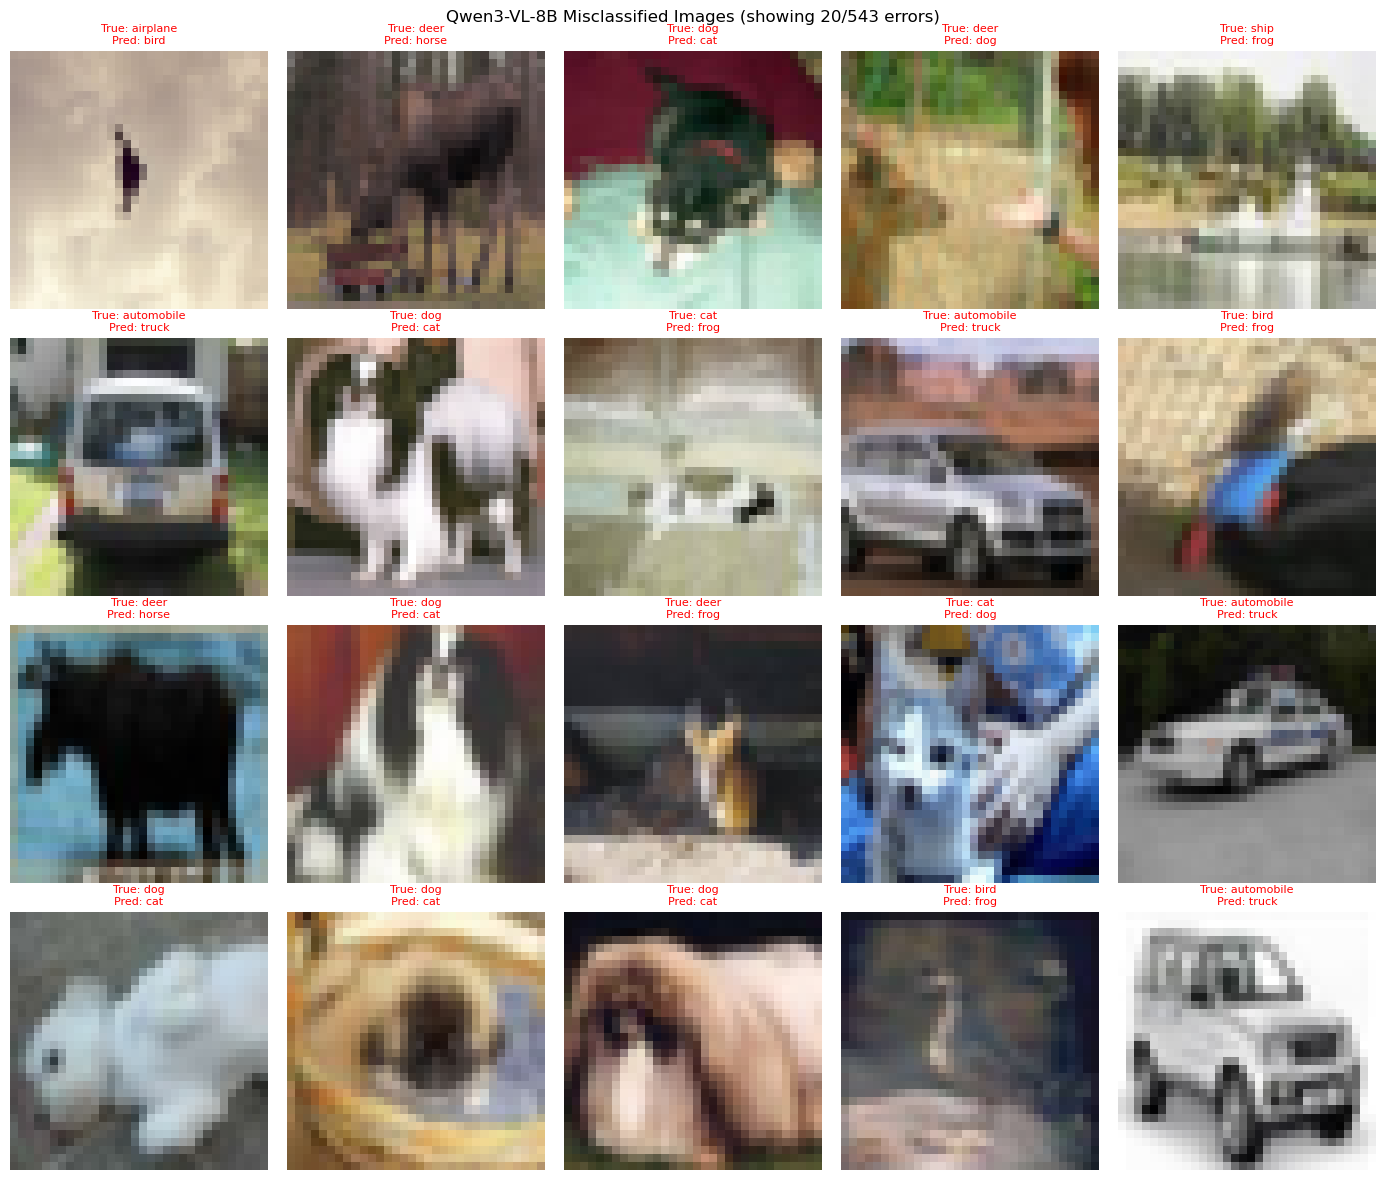

In [46]:
errors_q = [(int(indices[i]), pred, true)
             for i, (pred, true) in enumerate(zip(qwen_preds, qwen_true))
             if pred != true]

if not errors_q:
    print("No errors to display — perfect score on this subset!")
else:
    NUM_SHOW_Q = min(20, len(errors_q))
    cols_q = 5
    rows_q = (NUM_SHOW_Q + cols_q - 1) // cols_q

    fig, axes = plt.subplots(rows_q, cols_q, figsize=(14, rows_q * 3))
    axes = np.array(axes).reshape(-1)
    for ax, (idx, pred, true) in zip(axes, errors_q[:NUM_SHOW_Q]):
        img_t, _ = raw_test[idx]
        ax.imshow(tensor_to_pil(img_t))
        ax.set_title(f"True: {true}\nPred: {pred}", fontsize=8,
                     color='red' if pred != true else 'green')
        ax.axis('off')
    for ax in axes[NUM_SHOW_Q:]:
        ax.set_visible(False)
    plt.suptitle(f'Qwen3-VL-8B Misclassified Images (showing {NUM_SHOW_Q}/{len(errors_q)} errors)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()


In [23]:
# ── Free Qwen model from GPU memory ──────────────────────────────────────
del qwen_model, qwen_processor
gc.collect()
torch.cuda.empty_cache()
print("Qwen memory freed.")

Qwen memory freed.


---
## Section 5 — Gemma-4-31B-IT (Standard HuggingFace, Zero-Shot VLM)

Loads `google/gemma-4-31B-it` from the HuggingFace Hub.  
No training — each image is passed raw to the VLM with a prompt.

> **Prerequisites:** Request access at https://huggingface.co/google/gemma-4-31b-it and log in below.

### 5a — Evaluation Notes (Standard Gemma-4)

Fill in after running the evaluation below:

| Metric | Value |
|--------|-------|
| **Refusals** |  |
| **KL Divergence from baseline** | **0** *(by definition)* |
| **Overall accuracy** | *(fill in after running)* |
| **Notes** | *(any observations about failure modes, refusal patterns, etc.)* |

In [5]:
from huggingface_hub import login

# Log in with your HF token — or set HF_TOKEN env var beforehand
login()  # Opens an interactive prompt; alternatively: login(token="hf_xxx")

In [6]:
from transformers import AutoProcessor, AutoModelForCausalLM
import torch

GEMMA_MODEL_ID = "google/gemma-4-31B-it"

print(f"Loading processor for {GEMMA_MODEL_ID} ...")
gemma_processor = AutoProcessor.from_pretrained(GEMMA_MODEL_ID)

print(f"Loading model {GEMMA_MODEL_ID} ...")
gemma_model = AutoModelForCausalLM.from_pretrained(
    GEMMA_MODEL_ID,
    dtype="auto",
    device_map="auto",
)
gemma_model.eval()
print("Model loaded.")


Loading processor for google/gemma-4-31B-it ...
Loading model google/gemma-4-31B-it ...


Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]

Model loaded.


In [7]:
def gemma_recognize_batch(images, processor, model, max_new_tokens: int = 5) -> list[str]:
    """Batched zero-shot CIFAR-10 classification using a Gemma-4 model."""
    pil_images = [
        tensor_to_pil(img) if isinstance(img, torch.Tensor) else img
        for img in images
    ]

    batch_messages = [
        [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
            {"role": "user",   "content": [
                {"type": "image", "image": pil},
                {"type": "text",  "text": "What object is in this image?"},
            ]},
        ]
        for pil in pil_images
    ]

    inputs = processor.apply_chat_template(
        batch_messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
        padding=True,
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    results = []
    for out in outputs:
        raw     = processor.decode(out[input_len:], skip_special_tokens=False)
        result  = processor.parse_response(raw)
        text_out = result["content"].strip().lower()
        matched  = next((l for l in LABELS if l in text_out), text_out)
        results.append(matched)
    return results

# Single-image wrapper for demo cells
def gemma_recognize(image, processor, model, max_new_tokens: int = 5) -> str:
    return gemma_recognize_batch([image], processor, model, max_new_tokens)[0]

print("gemma_recognize / gemma_recognize_batch defined.")


gemma_recognize / gemma_recognize_batch defined.


#### 5b — Single-Image Demo (index 62)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/home/sam/.local/lib/python3.14/site-packages/transformers/integrations/sdpa_attention.py:92: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /build/python-pytorch/src/pytorch-rocm/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:377.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
/home/sam/.local/lib/python3.14/site-packages/transformers/integrations/sdpa_attention.py:92: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /build/python-pytorch/src/pytorch-rocm/aten/src/ATen/native/t

Gemma-4 predicts : frog
True label       : frog
Correct          : True


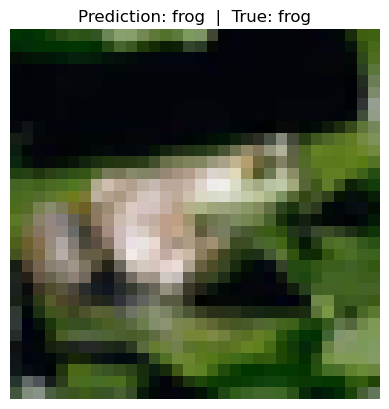

In [8]:
i = 62
img_tensor, true_label_idx = raw_test[i]

pred_gemma = gemma_recognize(img_tensor, gemma_processor, gemma_model)
true_label  = LABELS[true_label_idx]

print(f"Gemma-4 predicts : {pred_gemma}")
print(f"True label       : {true_label}")
print(f"Correct          : {pred_gemma == true_label}")

plt.imshow(tensor_to_pil(img_tensor))
plt.title(f"Prediction: {pred_gemma}  |  True: {true_label}", fontsize=12)
plt.axis('off')
plt.show()

#### 5c — Batch Evaluation ({NUM_SAMPLES} images)

In [9]:
import time
from tqdm.auto import tqdm

GEMMA_BATCH_SIZE = 10

gemma_preds, gemma_true = [], []
gemma_refusals = 0
start = time.time()

idx_list = list(indices)
for batch_start in tqdm(range(0, len(idx_list), GEMMA_BATCH_SIZE), desc="Gemma-4"):
    batch_idx = idx_list[batch_start : batch_start + GEMMA_BATCH_SIZE]
    imgs  = [raw_test[int(i)][0] for i in batch_idx]
    lbls  = [raw_test[int(i)][1] for i in batch_idx]
    preds = gemma_recognize_batch(imgs, gemma_processor, gemma_model)
    for pred, lbl in zip(preds, lbls):
        if pred not in LABELS:
            gemma_refusals += 1
        gemma_preds.append(pred)
        gemma_true.append(LABELS[lbl])

elapsed   = time.time() - start
n_correct = sum(p == t for p, t in zip(gemma_preds, gemma_true) if p in LABELS)
gemma_accuracy = n_correct / NUM_SAMPLES * 100

print(f"\nEvaluated {NUM_SAMPLES} images in {elapsed/60:.1f} min")
print(f"Refusals (invalid labels) : {gemma_refusals}")
print(f"Zero-shot accuracy        : {gemma_accuracy:.1f}%  ({n_correct}/{NUM_SAMPLES})")


Gemma-4:   0%|          | 0/1000 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform


Evaluated 10000 images in 380.2 min
Refusals (invalid labels) : 2
Zero-shot accuracy        : 93.2%  (9320/10000)


#### 5d — Per-Class Accuracy

Class         Correct   Total     Acc
--------------------------------------
airplane          941    1000   94.1%
automobile        966    1000   96.6%
bird              907    1000   90.7%
cat               877    1000   87.7%
deer              979    1000   97.9%
dog               923    1000   92.3%
frog              830    1000   83.0%
horse             930    1000   93.0%
ship              983    1000   98.3%
truck             984    1000   98.4%


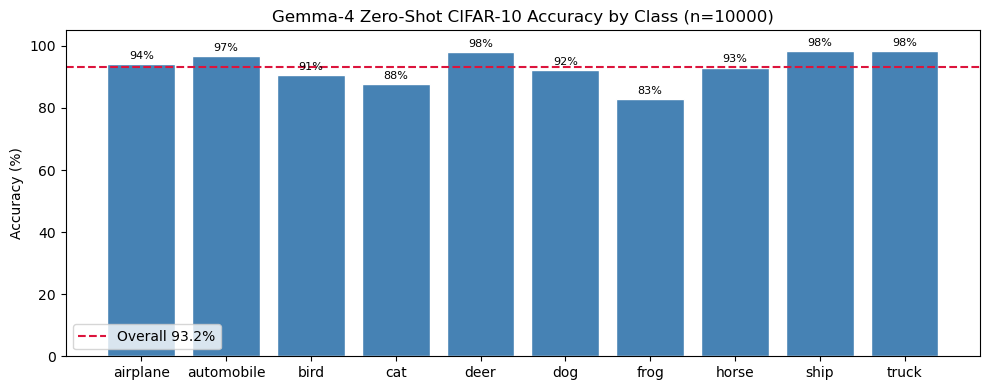

In [10]:
from collections import defaultdict

g_class_correct = defaultdict(int)
g_class_total   = defaultdict(int)

for pred, true in zip(gemma_preds, gemma_true):
    g_class_total[true] += 1
    if pred == true:
        g_class_correct[true] += 1

print(f"{'Class':<12}  {'Correct':>7}  {'Total':>6}  {'Acc':>6}")
print("-" * 38)
for label in LABELS:
    n   = g_class_total[label]
    c   = g_class_correct[label]
    acc = c / n * 100 if n > 0 else 0
    print(f"{label:<12}  {c:>7}  {n:>6}  {acc:>5.1f}%")

accs = [g_class_correct[l] / g_class_total[l] * 100 if g_class_total[l] > 0 else 0
        for l in LABELS]
plt.figure(figsize=(10, 4))
bars = plt.bar(LABELS, accs, color='steelblue', edgecolor='white')
plt.axhline(gemma_accuracy, color='crimson', linestyle='--',
            label=f'Overall {gemma_accuracy:.1f}%')
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title(f'Gemma-4 Zero-Shot CIFAR-10 Accuracy by Class (n={NUM_SAMPLES})')
plt.legend()
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

#### 5e — Confusion Matrix

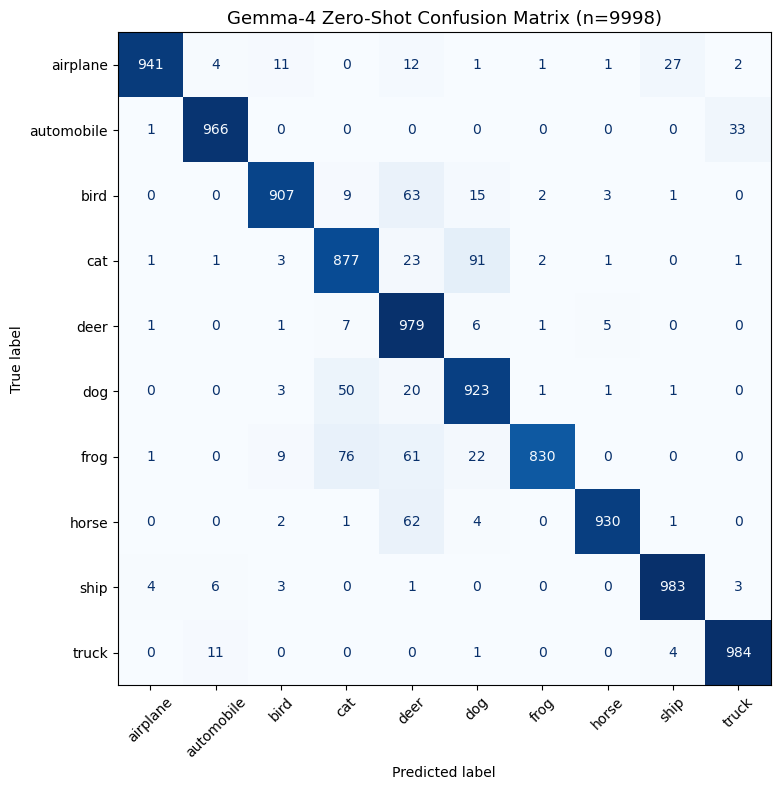

In [13]:
def label_to_idx(label):
    return LABELS.index(label) if label in LABELS else -1

y_true_g = [label_to_idx(l) for l in gemma_true]
y_pred_g = [label_to_idx(l) for l in gemma_preds]
pairs_g  = [(t, p) for t, p in zip(y_true_g, y_pred_g) if t >= 0 and p >= 0]
yt_g, yp_g = zip(*pairs_g)

cm_g = confusion_matrix(yt_g, yp_g, labels=range(10))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm_g, display_labels=LABELS).plot(ax=ax, colorbar=False,
                                                          cmap='Blues',
                                                          xticks_rotation=45)
ax.set_title(f'Gemma-4 Zero-Shot Confusion Matrix (n={len(pairs_g)})', fontsize=13)
plt.tight_layout()
plt.show()

#### 5f — Qualitative Error Analysis

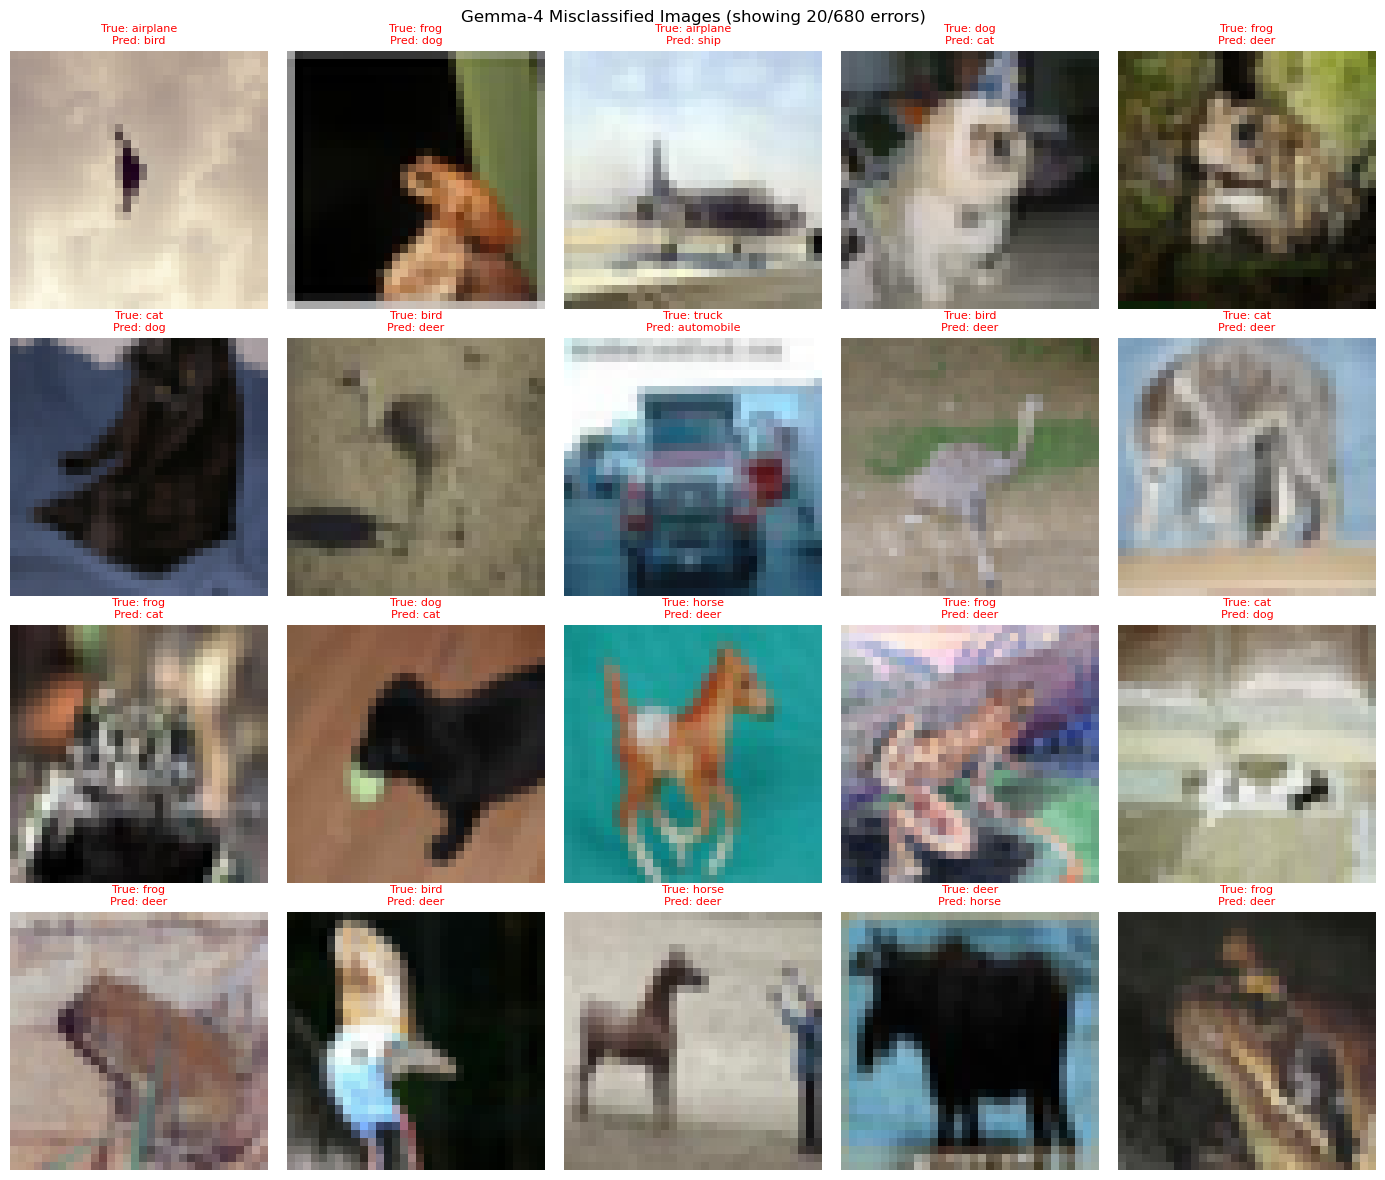

In [14]:
errors_g = [(int(indices[i]), pred, true)
             for i, (pred, true) in enumerate(zip(gemma_preds, gemma_true))
             if pred != true]

if not errors_g:
    print("No errors to display — perfect score on this subset!")
else:
    NUM_SHOW = min(20, len(errors_g))
    cols = 5
    rows = (NUM_SHOW + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
    axes = np.array(axes).reshape(-1)  # safe ravel for single-row case
    for ax, (idx, pred, true) in zip(axes, errors_g[:NUM_SHOW]):
        img_t, _ = raw_test[idx]
        ax.imshow(tensor_to_pil(img_t))
        ax.set_title(f"True: {true}\nPred: {pred}", fontsize=8,
                     color='red' if pred != true else 'green')
        ax.axis('off')
    for ax in axes[NUM_SHOW:]:
        ax.set_visible(False)
    plt.suptitle(f'Gemma-4 Misclassified Images (showing {NUM_SHOW}/{len(errors_g)} errors)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

In [15]:
# ── Free Gemma4 model from GPU memory ──────────────────────────────────────
import gc
del gemma_model, gemma_processor
gc.collect()
torch.cuda.empty_cache()
print("Gemma4 memory freed.")

Gemma4 memory freed.


---
## Section 6 — Gemma-4-31B Heretic2 (Local Directory, Zero-Shot VLM)

Loads the Heretic2 fine-tune from the local folder `./Gemma4:31b-Heretic2`.  
Uses the **same prompt, same evaluation subset (same indices), and same `NUM_SAMPLES`** as Section 5  
so results are directly comparable.

> **Note:** Place the model files in `./Gemma4:31b-Heretic2` relative to this notebook before running.

### 6a — Evaluation Notes (Gemma-4 Heretic2)

Fill in after running the evaluation below:

| Metric | Value |
|--------|-------|
| **Refusals** |  |
| **KL Divergence from Gemma-4 baseline** | *(fill in — e.g., computed from output logit distributions)* |
| **Overall accuracy** | *(fill in after running)* |
| **Notes** | *(any observations about differences from the baseline — e.g., fewer refusals, label drift, etc.)* |

In [16]:
import os
import json

HERETIC_PATH = "./Gemma4:31b-Heretic2"

# ── Patch missing preprocessor_config.json from the base Gemma4 processor ──
preprocessor_config_path = os.path.join(HERETIC_PATH, "preprocessor_config.json")
if not os.path.exists(preprocessor_config_path):
    print("preprocessor_config.json missing — copying from base Gemma4 processor ...")
    gemma_processor.image_processor.save_pretrained(HERETIC_PATH)
    print("Patched.")

print(f"Loading Heretic2 processor from {HERETIC_PATH} ...")
heretic_processor = AutoProcessor.from_pretrained(HERETIC_PATH)

print(f"Loading Heretic2 model from {HERETIC_PATH} ...")
heretic_model = AutoModelForCausalLM.from_pretrained(
    HERETIC_PATH,
    dtype="auto",
    device_map="auto",
)
heretic_model.eval()
print("Heretic2 model loaded.")


Loading Heretic2 processor from ./Gemma4:31b-Heretic2 ...
Loading Heretic2 model from ./Gemma4:31b-Heretic2 ...


Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]

Heretic2 model loaded.


#### 6b — Single-Image Demo (index 62)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Heretic2 predicts : frog
True label        : frog
Correct           : True


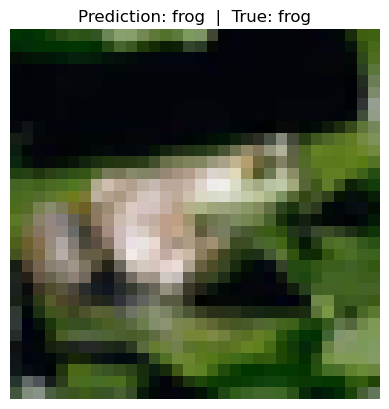

In [17]:
i = 62
img_tensor, true_label_idx = raw_test[i]

pred_heretic = gemma_recognize(img_tensor, heretic_processor, heretic_model)
true_label   = LABELS[true_label_idx]

print(f"Heretic2 predicts : {pred_heretic}")
print(f"True label        : {true_label}")
print(f"Correct           : {pred_heretic == true_label}")

plt.imshow(tensor_to_pil(img_tensor))
plt.title(f"Prediction: {pred_heretic}  |  True: {true_label}", fontsize=12)
plt.axis('off')
plt.show()

#### 6c — Batch Evaluation ({NUM_SAMPLES} images — same indices as Section 5)

In [18]:
# Uses the shared indices from Section 0b.
# Identical indices to all other sections — results are directly comparable.

HERETIC_BATCH_SIZE = 20

heretic_preds, heretic_true = [], []
heretic_refusals = 0
start_h = time.time()

idx_list = list(indices)
for batch_start in tqdm(range(0, len(idx_list), HERETIC_BATCH_SIZE), desc="Heretic2"):
    batch_idx = idx_list[batch_start : batch_start + HERETIC_BATCH_SIZE]
    imgs  = [raw_test[int(i)][0] for i in batch_idx]
    lbls  = [raw_test[int(i)][1] for i in batch_idx]
    preds = gemma_recognize_batch(imgs, heretic_processor, heretic_model)
    for pred, lbl in zip(preds, lbls):
        if pred not in LABELS:
            heretic_refusals += 1
        heretic_preds.append(pred)
        heretic_true.append(LABELS[lbl])

elapsed_h        = time.time() - start_h
n_correct_h      = sum(p == t for p, t in zip(heretic_preds, heretic_true) if p in LABELS)
heretic_accuracy = n_correct_h / NUM_SAMPLES * 100

print(f"\nEvaluated {NUM_SAMPLES} images in {elapsed_h/60:.1f} min")
print(f"Refusals (invalid labels) : {heretic_refusals}")
print(f"Zero-shot accuracy        : {heretic_accuracy:.1f}%  ({n_correct_h}/{NUM_SAMPLES})")


Heretic2:   0%|          | 0/500 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform


Evaluated 10000 images in 392.3 min
Refusals (invalid labels) : 0
Zero-shot accuracy        : 91.7%  (9166/10000)


#### 6d — Per-Class Accuracy

Class         Correct   Total     Acc
--------------------------------------
airplane          944    1000   94.4%
automobile        969    1000   96.9%
bird              854    1000   85.4%
cat               916    1000   91.6%
deer              977    1000   97.7%
dog               751    1000   75.1%
frog              862    1000   86.2%
horse             945    1000   94.5%
ship              971    1000   97.1%
truck             977    1000   97.7%


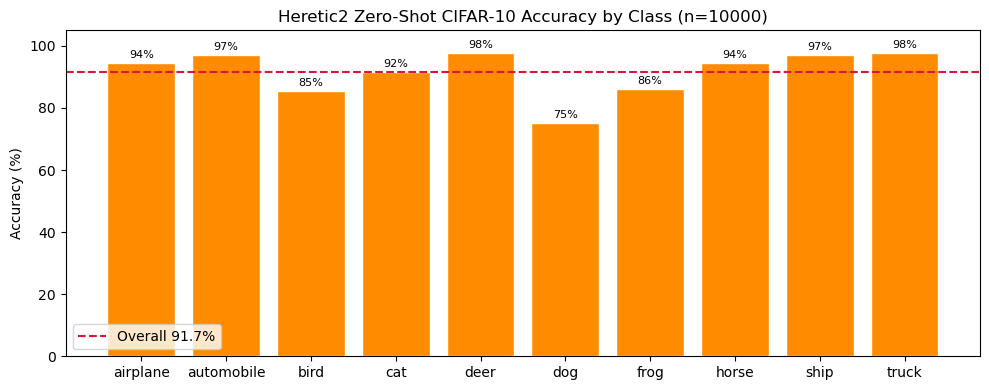

In [19]:
h_class_correct = defaultdict(int)
h_class_total   = defaultdict(int)

for pred, true in zip(heretic_preds, heretic_true):
    h_class_total[true] += 1
    if pred == true:
        h_class_correct[true] += 1

print(f"{'Class':<12}  {'Correct':>7}  {'Total':>6}  {'Acc':>6}")
print("-" * 38)
for label in LABELS:
    n   = h_class_total[label]
    c   = h_class_correct[label]
    acc = c / n * 100 if n > 0 else 0
    print(f"{label:<12}  {c:>7}  {n:>6}  {acc:>5.1f}%")

accs_h = [h_class_correct[l] / h_class_total[l] * 100 if h_class_total[l] > 0 else 0
          for l in LABELS]
plt.figure(figsize=(10, 4))
bars = plt.bar(LABELS, accs_h, color='darkorange', edgecolor='white')
plt.axhline(heretic_accuracy, color='crimson', linestyle='--',
            label=f'Overall {heretic_accuracy:.1f}%')
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title(f'Heretic2 Zero-Shot CIFAR-10 Accuracy by Class (n={NUM_SAMPLES})')
plt.legend()
for bar, acc in zip(bars, accs_h):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

#### 6e — Confusion Matrix

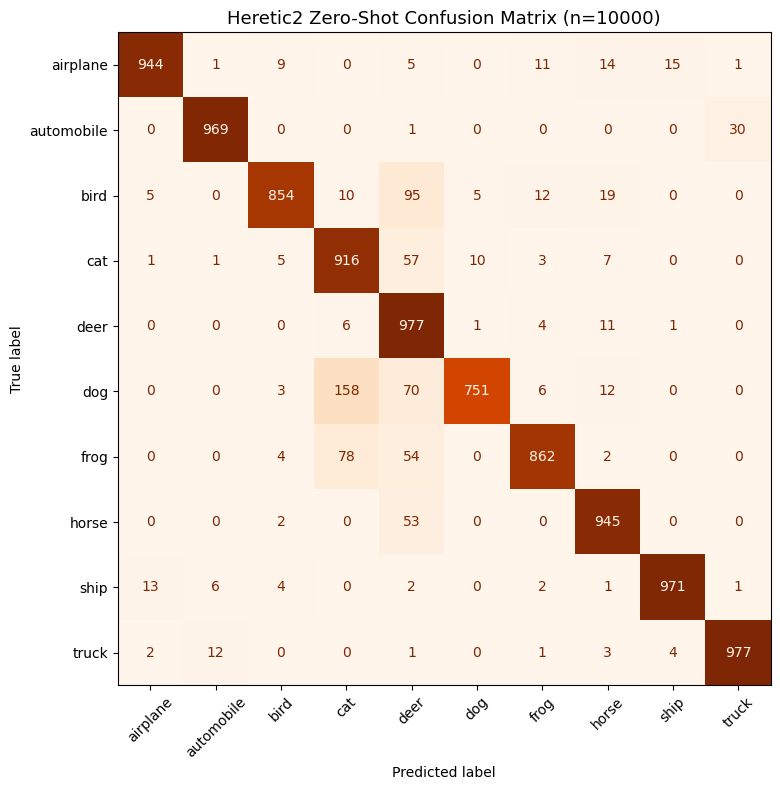

In [20]:
y_true_h = [label_to_idx(l) for l in heretic_true]
y_pred_h = [label_to_idx(l) for l in heretic_preds]
pairs_h  = [(t, p) for t, p in zip(y_true_h, y_pred_h) if t >= 0 and p >= 0]
yt_h, yp_h = zip(*pairs_h)

cm_h = confusion_matrix(yt_h, yp_h, labels=range(10))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm_h, display_labels=LABELS).plot(ax=ax, colorbar=False,
                                                          cmap='Oranges',
                                                          xticks_rotation=45)
ax.set_title(f'Heretic2 Zero-Shot Confusion Matrix (n={len(pairs_h)})', fontsize=13)
plt.tight_layout()
plt.show()

#### 6f — Qualitative Error Analysis

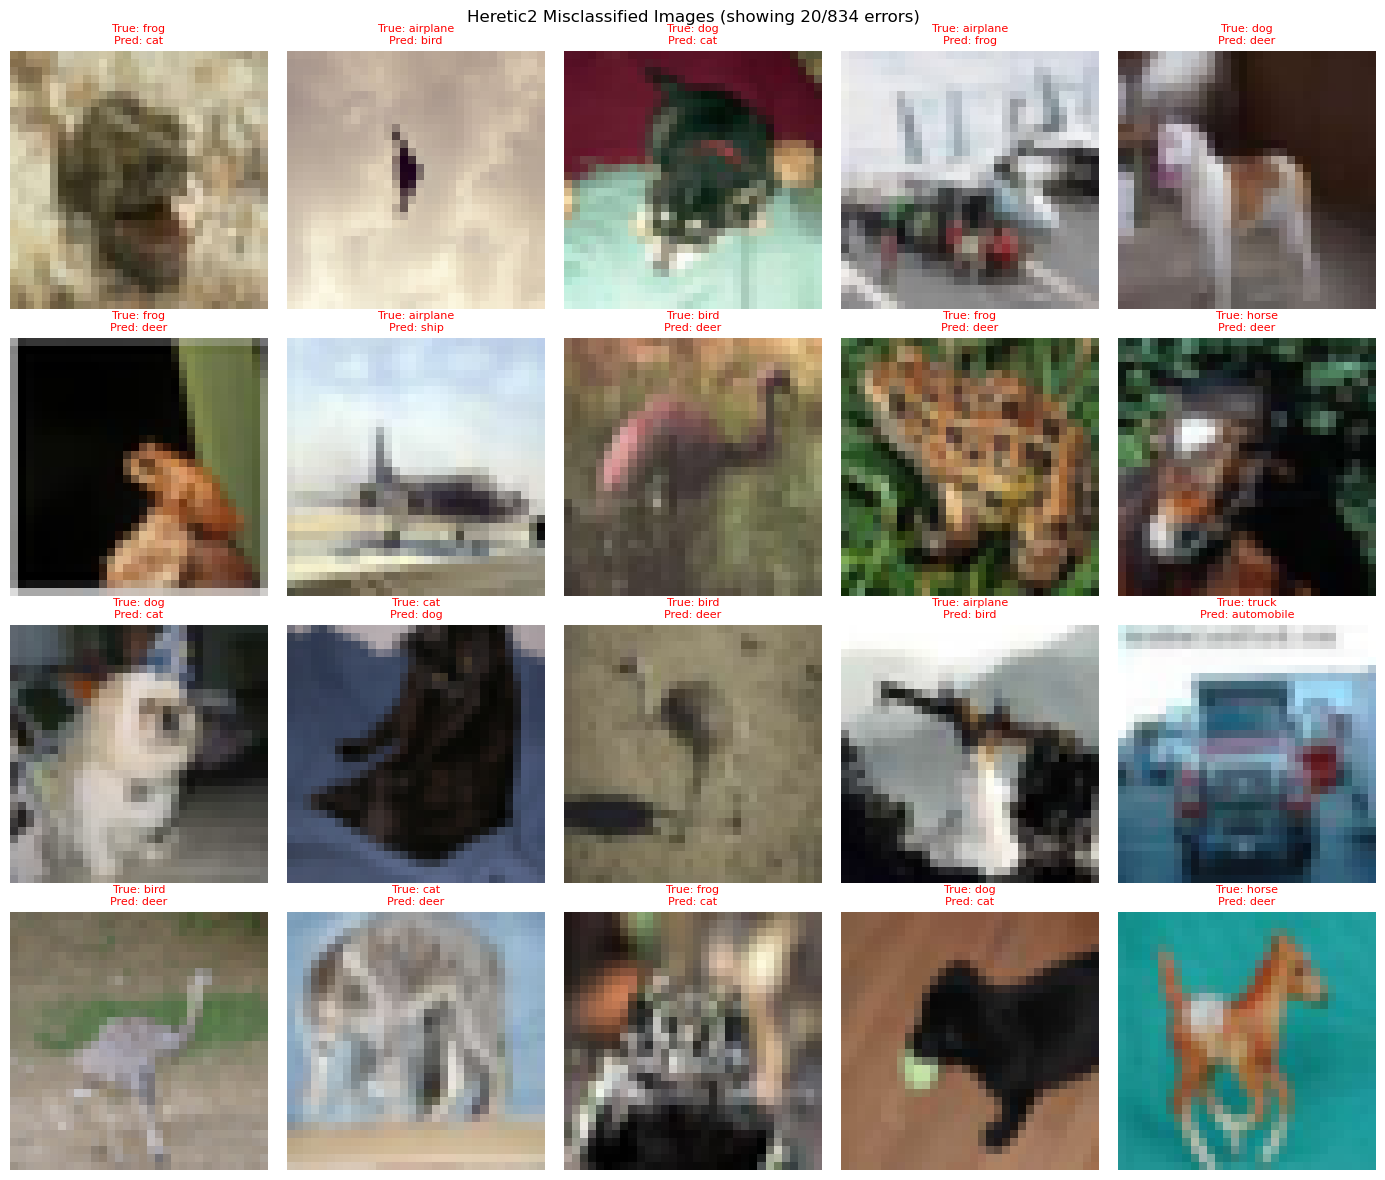

In [21]:
errors_h = [(int(indices[i]), pred, true)
             for i, (pred, true) in enumerate(zip(heretic_preds, heretic_true))
             if pred != true]

if not errors_h:
    print("No errors to display — perfect score on this subset!")
else:
    NUM_SHOW_H = min(20, len(errors_h))
    cols_h = 5
    rows_h = (NUM_SHOW_H + cols_h - 1) // cols_h

    fig, axes = plt.subplots(rows_h, cols_h, figsize=(14, rows_h * 3))
    axes = np.array(axes).reshape(-1)
    for ax, (idx, pred, true) in zip(axes, errors_h[:NUM_SHOW_H]):
        img_t, _ = raw_test[idx]
        ax.imshow(tensor_to_pil(img_t))
        ax.set_title(f"True: {true}\nPred: {pred}", fontsize=8,
                     color='red' if pred != true else 'green')
        ax.axis('off')
    for ax in axes[NUM_SHOW_H:]:
        ax.set_visible(False)
    plt.suptitle(f'Heretic2 Misclassified Images (showing {NUM_SHOW_H}/{len(errors_h)} errors)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

In [22]:
# ── Free Heretic model from GPU memory ──────────────────────────────────────
import gc
del heretic_model, heretic_processor
gc.collect()
torch.cuda.empty_cache()
print("Heretic memory freed.")

Heretic memory freed.


#### 6g — Side-by-Side Comparison: Gemma-4 vs Heretic2

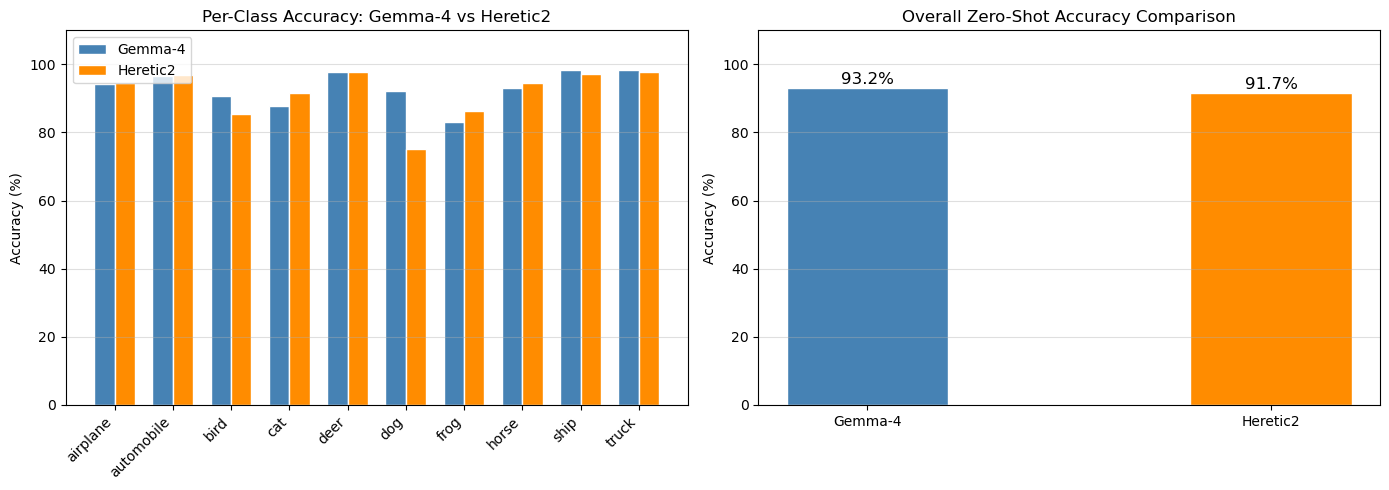

Gemma-4  accuracy : 93.2%  | refusals: 2
Heretic2 accuracy : 91.7%  | refusals: 0


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-class accuracy bars
x = np.arange(len(LABELS))
w = 0.35
axes[0].bar(x - w/2, accs,   w, label='Gemma-4',  color='steelblue',  edgecolor='white')
axes[0].bar(x + w/2, accs_h, w, label='Heretic2', color='darkorange', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABELS, rotation=45, ha='right')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Per-Class Accuracy: Gemma-4 vs Heretic2')
axes[0].legend()
axes[0].set_ylim(0, 110)
axes[0].grid(axis='y', alpha=0.4)

# Overall accuracy bar
axes[1].bar(['Gemma-4', 'Heretic2'], [gemma_accuracy, heretic_accuracy],
            color=['steelblue', 'darkorange'], edgecolor='white', width=0.4)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Overall Zero-Shot Accuracy Comparison')
axes[1].set_ylim(0, 110)
for i, v in enumerate([gemma_accuracy, heretic_accuracy]):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Gemma-4  accuracy : {gemma_accuracy:.1f}%  | refusals: {gemma_refusals}")
print(f"Heretic2 accuracy : {heretic_accuracy:.1f}%  | refusals: {heretic_refusals}")

---
## Section 7 — All-Methods Accuracy Comparison

Side-by-side vertical bar chart comparing all five evaluated methods:
**FCNN · CNN · Qwen3-VL-8B-Instruct · Gemma4:31b-it · Gemma4:31b-heretic**

> All five methods are evaluated on the **same `NUM_SAMPLES` random subset** of the test set for a fair comparison.  
> FCNN and CNN are **trained** on the full training set, but **evaluated** on the same subset as the VLMs.


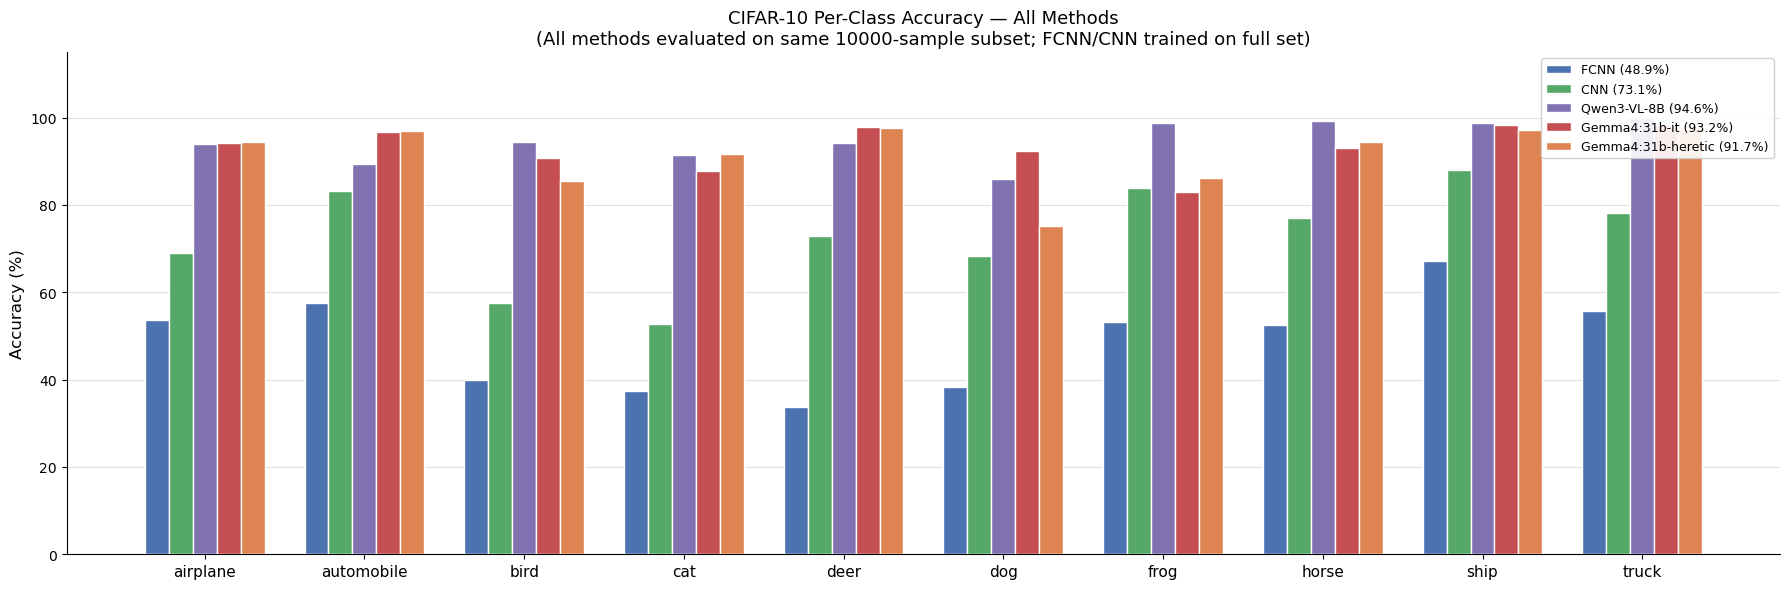


── Final Results Summary ─────────────────
  Method                     Overall  airpl  autom   bird    cat   deer    dog   frog  horse   ship  truck
  ---------------------------------------------------------------------------------------------------------
  FCNN                         48.9%   53.7   57.5   39.9   37.3   33.8   38.3   53.2   52.4   67.2   55.8
  CNN                          73.1%   69.0   83.2   57.6   52.8   72.8   68.4   83.9   77.0   87.9   78.2
  Qwen3-VL-8B                  94.6%   93.9   89.3   94.4   91.5   94.1   85.9   98.7   99.3   98.7   99.9
  Gemma4:31b-it                93.2%   94.1   96.6   90.7   87.7   97.9   92.3   83.0   93.0   98.3   98.4
  Gemma4:31b-heretic           91.7%   94.4   96.9   85.4   91.6   97.7   75.1   86.2   94.5   97.1   97.7


In [47]:
import numpy as np

# ── Per-class accuracy for FCNN ───────────────────────────────────────────────
fcnn_class_correct = defaultdict(int)
fcnn_class_total   = defaultdict(int)
for pred, true in zip(all_preds, all_true):
    fcnn_class_total[true] += 1
    if pred == true:
        fcnn_class_correct[true] += 1
accs_fcnn = [fcnn_class_correct[i] / fcnn_class_total[i] * 100
             if fcnn_class_total[i] > 0 else 0 for i in range(10)]

# ── Per-class accuracy for CNN ────────────────────────────────────────────────
cnn_class_correct = defaultdict(int)
cnn_class_total   = defaultdict(int)
for pred, true in zip(all_preds_cnn, all_true_cnn):
    cnn_class_total[true] += 1
    if pred == true:
        cnn_class_correct[true] += 1
accs_cnn = [cnn_class_correct[i] / cnn_class_total[i] * 100
            if cnn_class_total[i] > 0 else 0 for i in range(10)]

# ── All per-class accuracy arrays (already computed in earlier sections) ──────
# accs_q  = Qwen3-VL  (from Section 4d)
# accs    = Gemma4-it (from Section 5d)
# accs_h  = Heretic2  (from Section 6d)

method_names      = ['FCNN', 'CNN', 'Qwen3-VL-8B', 'Gemma4:31b-it', 'Gemma4:31b-heretic']
method_accs       = [accs_fcnn, accs_cnn, accs_q, accs, accs_h]
method_overall    = [fcnn_acc, cnn_acc, qwen_accuracy, gemma_accuracy, heretic_accuracy]
colors            = ['#4C72B0', '#55A868', '#8172B2', '#C44E52', '#DD8452']

x  = np.arange(len(LABELS))
n  = len(method_names)
w  = 0.15                          # width of each individual bar
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * w

fig, ax = plt.subplots(figsize=(18, 6))

for i, (name, accs_m, color, overall) in enumerate(
        zip(method_names, method_accs, colors, method_overall)):
    bars = ax.bar(x + offsets[i], accs_m, w, label=f'{name} ({overall:.1f}%)',
                  color=color, edgecolor='white', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title(
    f'CIFAR-10 Per-Class Accuracy — All Methods\n'
    f'(All methods evaluated on same {NUM_SAMPLES}-sample subset; FCNN/CNN trained on full set)',
    fontsize=13
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n── Final Results Summary ─────────────────")
print(f"  {'Method':<25} {'Overall':>8}  " + "  ".join(f"{l[:5]:>5}" for l in LABELS))
print("  " + "-" * (25 + 8 + 2 + 7 * 10))
for name, accs_m, overall in zip(method_names, method_accs, method_overall):
    row = "  ".join(f"{a:>5.1f}" for a in accs_m)
    print(f"  {name:<25} {overall:>7.1f}%  {row}")